In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = "/content/drive/MyDrive/dataset/dogscats/valid"

In [ ]:
train_transformation = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.RandomRotation(degrees=5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5,0.5,0.5],
        std  = [0.25,0.25,0.25]
    )
])
test_transformation = train_transformation = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5,0.5,0.5],
        std  = [0.25,0.25,0.25]
    )
])

In [ ]:
dataset = datasets.ImageFolder(root = data,transform = transformation )

In [ ]:
print(dataset.classes)
print(dataset.class_to_idx)

['cats', 'dogs']
{'cats': 0, 'dogs': 1}


In [ ]:
print(len(dataset))

2010


In [ ]:
train_set = int(0.8*len(dataset))
test_set =len(dataset)-train_set
print(train_set,test_set)

1608 402


In [ ]:
train_datset, test_dataset = random_split(dataset,[train_set,test_set])

In [ ]:
train_loader = DataLoader(train_datset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

In [ ]:
# for image,label in train_loader:
#   print(image)
#   print(label)

In [ ]:
model = SimpleCNN().to(device)
loss_fxn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)


In [ ]:
loss_history = []
acc_history = []

In [ ]:
for epoch in range(1,11):
  model.train()
  batch_loss = 0
  correct = 0
  for image, label in train_loader:
    image = image.to(device)
    label = label.to(device)
    #Feed Forward
    output = model(image)
    loss = loss_fxn(output,label)
    #backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #capturing loss
    batch_loss += loss.item()
    predict = torch.argmax(output,dim = 1)
    correct += (predict == label).sum().item()
  epoch_loss = batch_loss / len(train_loader)
  loss_history.append(epoch_loss)
  epoch_acc =  (correct/1608)*100
  acc_history.append(epoch_acc)
  print(f"for epoch {epoch},loss = {epoch_loss},accurcy = {epoch_acc}")







for epoch 1,loss = 0.8417113016147425,accurcy = 51.11940298507462
for epoch 2,loss = 0.6890668981146104,accurcy = 53.79353233830846
for epoch 3,loss = 0.6748112687970153,accurcy = 55.41044776119403
for epoch 4,loss = 0.6667612785159951,accurcy = 57.2139303482587
for epoch 5,loss = 0.639023611746212,accurcy = 58.582089552238806
for epoch 6,loss = 0.6102817775589404,accurcy = 64.11691542288557
for epoch 7,loss = 0.5783897478981773,accurcy = 65.4228855721393
for epoch 8,loss = 0.5181394172186898,accurcy = 70.21144278606965
for epoch 9,loss = 0.44867336469711644,accurcy = 77.48756218905473
for epoch 10,loss = 0.3773352759014262,accurcy = 82.96019900497512


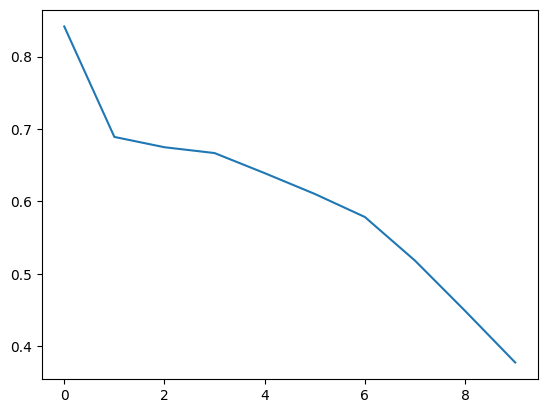

In [ ]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.show()

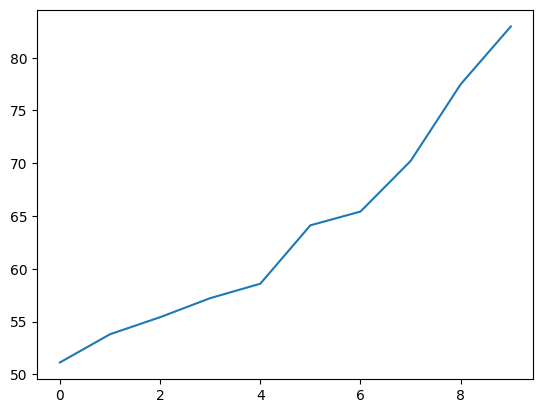

In [ ]:
plt.plot(acc_history)
plt.show()

In [ ]:
torch.save(model.state_dict(),"CNN_Simple.pth")

In [ ]:
model1 = SimpleCNN().to(device)

In [ ]:
model1.load_state_dict(torch.load("CNN_Simple.pth",map_location=device,weights_only=True))

<All keys matched successfully>

In [ ]:
from PIL import Image
_image = Image.open("/content/drive/MyDrive/dataset/dogscats/test1/10002.jpg").convert("RGB")
image_tensor = transformation(_image)
tensor_image = image_tensor.unsqueeze(0).to(device)
model1.eval()
with torch.no_grad():
  output =  model1(tensor_image)
  predict = torch.argmax(output,1)
  print(predict)

tensor([1], device='cuda:0')
